# 02 · Load, pre-process, and train the model
### DINO-4DSTEM tutorials

We now teach a neural network to sort the WS2 diffraction patterns into classes
**with no labels**. This notebook explains *how* that self-supervised training
works, the pre-processing it needs, and the parameters — then runs a short
training so you can watch it happen.

**You will:** load the cube -> see what the network is actually fed ->
understand the DINO training loop -> train a small model.

## 1 · The idea — self-supervised learning (DINO)

There are no ground-truth labels, so we can't do ordinary supervised training.
**DINO** (self-**di**stillation with **no** labels) instead makes the model teach
itself:

- Two networks with the same architecture — a **student** $f_s$ and a
  **teacher** $f_t$.
- Each diffraction pattern $x$ is shown as **two randomly augmented views**
  $x_1, x_2$ (here: random rotations of the pattern, small blur/brightness).
- Both networks map a view to a probability vector over $K$ **prototypes**
  (cluster centres): $p = \mathrm{softmax}(f(x)/\tau)$.
- **Objective:** the student's distribution for one view should match the
  *teacher's* for the other view — a cross-entropy loss

$$\mathcal{L} = -\sum_{k} p_t(x_2)_k \,\log p_s(x_1)_k .$$

- The **teacher is never trained by gradient descent**; it's an *exponential
  moving average* (EMA) of the student:
  $\theta_t \leftarrow m\,\theta_t + (1-m)\,\theta_s$. This makes it a slowly
  changing, more stable target.

**Avoiding collapse.** Nothing above stops the model from mapping *everything*
to one prototype. DINO prevents that with two opposing forces on the teacher:
- **centering** (subtract a running mean of teacher outputs) — spreads usage out;
- **sharpening** (a low teacher temperature $\tau_t$) — keeps targets confident.
Balanced, they give distinct, well-used classes.

## 2 · Rotation invariance — the polar transform

In our WS2 phantom each grain is spun to a **random in-plane angle**, but that
rotation should *not* change the class. We build that invariance in two ways:

1. **Polar transform.** Each pattern is unwrapped from Cartesian $(x,y)$ to
   polar $(r,\theta)$. An in-plane rotation is then just a **shift along the
   $\theta$ axis** — much easier for the network to become invariant to.
2. **$\theta$-roll augmentation.** The two views are rolled by random amounts
   along $\theta$, so the network learns that a $\theta$-shift = same pattern.

The beam is masked out (the central disk carries no orientation information).

In [1]:
import os, numpy as np
import ws2_utils as wu
wu.add_src_to_path(); wu.preimport()      # import model modules before inline
%matplotlib inline
import matplotlib.pyplot as plt

ex = wu.find_ws2_example()
cube_path = os.path.join(ex, 'phantom.cube.npy')
import json
meta = json.load(open(os.path.join(ex, 'phantom.sim_meta.json')))
VMAX = 50.0    # display/normalisation cap used for this WS2 model

## 3 · Load the data & see the input

`LoadPRZ` wraps the cube and turns each raw pattern into the network's input:
it resizes to 192 px and **normalises intensity** by a contrast cap `vmax`
(counts above `vmax` are clipped, then scaled to `[0,1]`) — so a bright grain
and a dim grain look comparable. `ds[i]` returns that normalised tensor;
`ds.get_raw(i)` gives the untouched pattern.

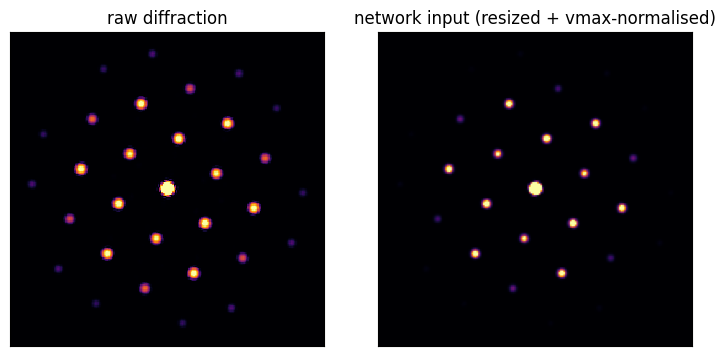

In [2]:
from data import LoadPRZ
ds = LoadPRZ(cube_path, resize=192, vmax=VMAX)
i = 96*48 + 48                                  # a probe near the middle
raw   = ds.get_raw(i)                           # untouched pattern
model_in = ds[i][0].numpy()                     # normalised network input

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.6))
wu.logshow(ax[0], raw);  ax[0].set_title('raw diffraction')
ax[1].imshow(model_in, cmap='inferno'); ax[1].set_title('network input (resized + vmax-normalised)')
ax[1].set_xticks([]); ax[1].set_yticks([]); plt.tight_layout(); plt.show()

### The polar view

Here is the same pattern unwrapped to polar coordinates. The concentric Bragg
rings become **horizontal bands**, and an in-plane rotation would slide the
image left/right — which is why a shift-augmentation along $\theta$ teaches
rotation invariance. (Illustrative unwrap; the model uses the library's exact
polar transform.)

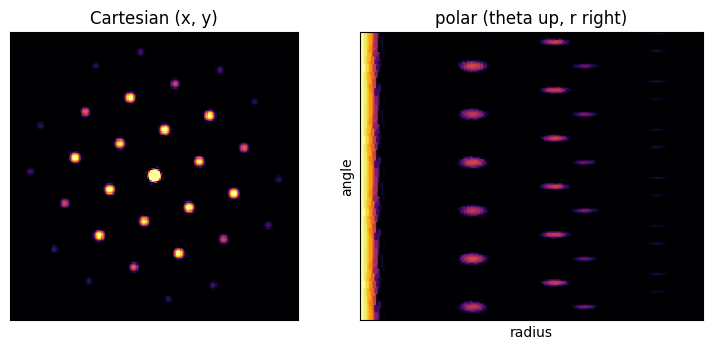

In [3]:
import cv2
h, w = raw.shape; cy, cx = (h-1)/2.0, (w-1)/2.0
polar = cv2.warpPolar(raw.astype(np.float32), (192, 192), (cx, cy),
                      min(cy, cx), cv2.WARP_POLAR_LINEAR)      # rows=theta, cols=r
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.6))
wu.logshow(ax[0], raw); ax[0].set_title('Cartesian (x, y)')
ax[1].imshow(np.log1p(polar), cmap='inferno', aspect='auto')
ax[1].set_title('polar (theta up, r right)'); ax[1].set_xlabel('radius'); ax[1].set_ylabel('angle')
ax[1].set_xticks([]); ax[1].set_yticks([]); plt.tight_layout(); plt.show()

## 4 · The training recipe

| parameter | value | what it does |
|---|---|---|
| `num_prototypes` (K) | 60 | max number of classes; **over-provisioned** — the model auto-prunes to the few it needs |
| `epochs` | 30 (full) | passes over the data |
| `lr` | 3e-4 | AdamW learning rate |
| `T0 -> Tfin` | 0.04 -> 0.07 | teacher temperature (sharpening); warms up over training |
| `EMA0 -> EMAfin` | 0.990 -> 0.999 | teacher EMA momentum; teacher tracks the student ever more slowly |
| `center_crop_size` | 135 | keep the informative rings, drop high-angle noise |
| `polar_mask_cols` | 30 | mask the central beam in polar space |
| `center_mask_radius` | 15 | beam-mask radius |
| `contrastive_lambda` | 0.2 | weight of the extra contrastive term (variant "c") |

Below we run a **short demo** (5 epochs on a 1500-pattern subsample, ~30 s) just
to see training work. The full result used in notebook 03 is the provided
30-epoch checkpoint.

In [4]:
from dino_sr_contrastive_model import (ContrastiveDINOModel,
                                        get_contrastive_transforms, train_contrastive)

s_aug, t_aug, s_roll, t_roll = get_contrastive_transforms(
    center_mask_radius=15, center_crop_size=135, polar_size=192,
    polar_mask_cols=30, theta_roll_aug=True, com_centering=False)

model = ContrastiveDINOModel(num_prototypes=60, T0=0.04, Tfin=0.07,
    center_momentum=0.97, EMA0=0.990, EMAfin=0.999, circular_theta=True)

run_dir = os.path.join(wu.repo_root(), 'runs', '_gui', 'tutorial_train')
model, timing = train_contrastive(
    model, ds, epochs=5, lr=3e-4, outdir=run_dir, seed=42, batch_size=128,
    student_aug=s_aug, teacher_aug=t_aug, student_roll=s_roll, teacher_roll=t_roll,
    contrastive_lambda=0.2, subsample_n=1500)

[finetune] DataLoader restricted to 1500/9216 patterns (SubsetRandomSampler, seed=42). Pair-loss endpoints unrestricted.


tutorial_train:   0%|                                                         | 0/5 [00:00<?, ?it/s]


[ASYMMETRY-CHECK] OK: student/teacher theta-roll differ for 127/128 samples (first-batch collision count 1 is consistent with independent RNG over shift_range=192).


In [5]:
ckpts = sorted(f for f in os.listdir(run_dir) if f.endswith('.pth'))
print('saved checkpoint ->', os.path.join(run_dir, 'best.pth'))

saved checkpoint -> D:\DINOSR\Claude\PaperRun_claude\dino_sr_contrastive\runs\_gui\tutorial_train\best.pth


### Done

You saw what the network is fed, why the polar transform gives rotation
invariance, and trained a small DINO model. A checkpoint (`best.pth`) is saved.

**Next -> `03_analyze_classmap.ipynb`**: run a trained model, get the class map,
and measure it against the ground truth. (03 uses the full 30-epoch checkpoint
for the headline numbers; you can point it at your `tutorial_train` model too.)